# Fontana Emanuele, Thresholding #

### Import library ###

In [1]:
import cv2
import matplotlib.pyplot as plt

Low-Level processing

(490, 637)


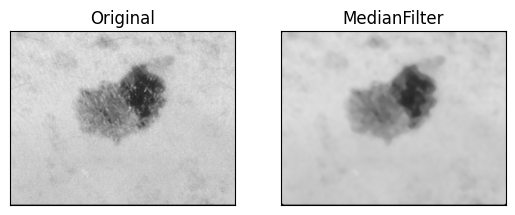

In [2]:
img= cv2.imread('skin.jpeg')
original = img.copy()
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(img.shape)
#adding a zero padding to the image
img = cv2.copyMakeBorder(img, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)
smooth = cv2.medianBlur(img, 13)
#plot the two images
plt.subplot(121), plt.imshow(img, cmap='gray',vmin=0, vmax=255)
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(smooth, cmap='gray',vmin=0, vmax=255)
plt.title('MedianFilter'), plt.xticks([]), plt.yticks([])
plt.show()
img=smooth


## Histogram of the filtered image ##

Text(0.5, 1.0, 'Histogram')

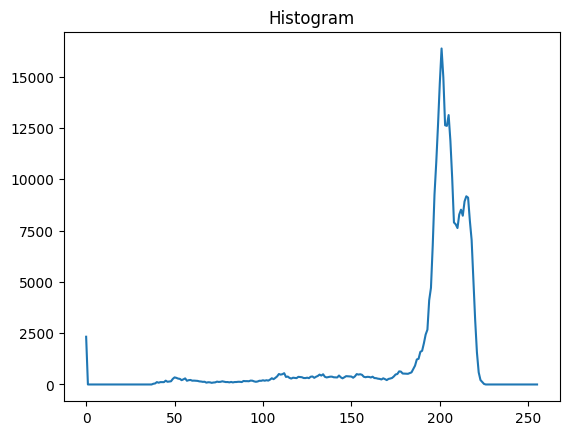

In [3]:
histogram = cv2.calcHist([img], [0], None, [256], [0, 256])
plt.plot(histogram)
plt.title('Histogram')

According to me, the optimal threshold is about 190. Let's compare this with the Otsu method

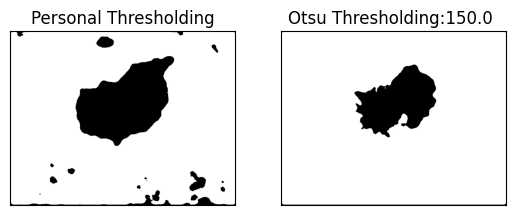

In [4]:
#personal thresholding
personalThreshold = 190
image = cv2.threshold(img.copy(), personalThreshold, 255, cv2.THRESH_BINARY)[1]
otsuThreshold, otsuImage = cv2.threshold(img.copy(), 0, 255,cv2.THRESH_OTSU)

#plot the two images
plt.subplot(121), plt.imshow(image, cmap='gray',vmin=0, vmax=255)
plt.title('Personal Thresholding'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(otsuImage, cmap='gray',vmin=0, vmax=255)
plt.title(f"Otsu Thresholding:{otsuThreshold} "), plt.xticks([]), plt.yticks([])
plt.show()

Otsu method return a better threshold value, as expected

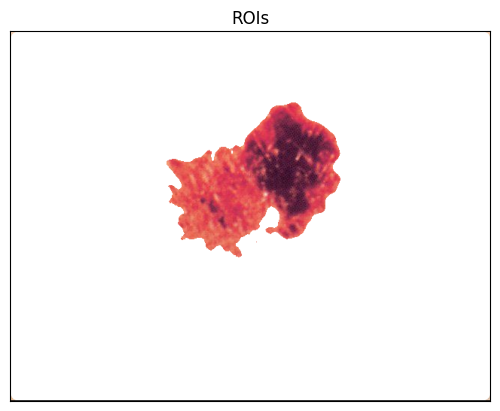

In [16]:
binary_mask = otsuImage
new_image=img = cv2.copyMakeBorder(original, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)
colored = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)
R, G, B = cv2.split(colored)
R=R| binary_mask
G=G| binary_mask
B=B | binary_mask
new_image = cv2.merge((R, G, B))
plt.title('ROIs')
plt.imshow(new_image,vmin=0,vmax=255)
plt.show(plt.xticks([]), plt.yticks([]))